<a href="https://colab.research.google.com/github/caviteri/Ciencia-de-Datos-2026/blob/main/Ciencia_de_Datos_Semana_09_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Taller: PCA - Principal Component Analysis

Maestría en Ingeniería Electrónica (MaIE)

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera

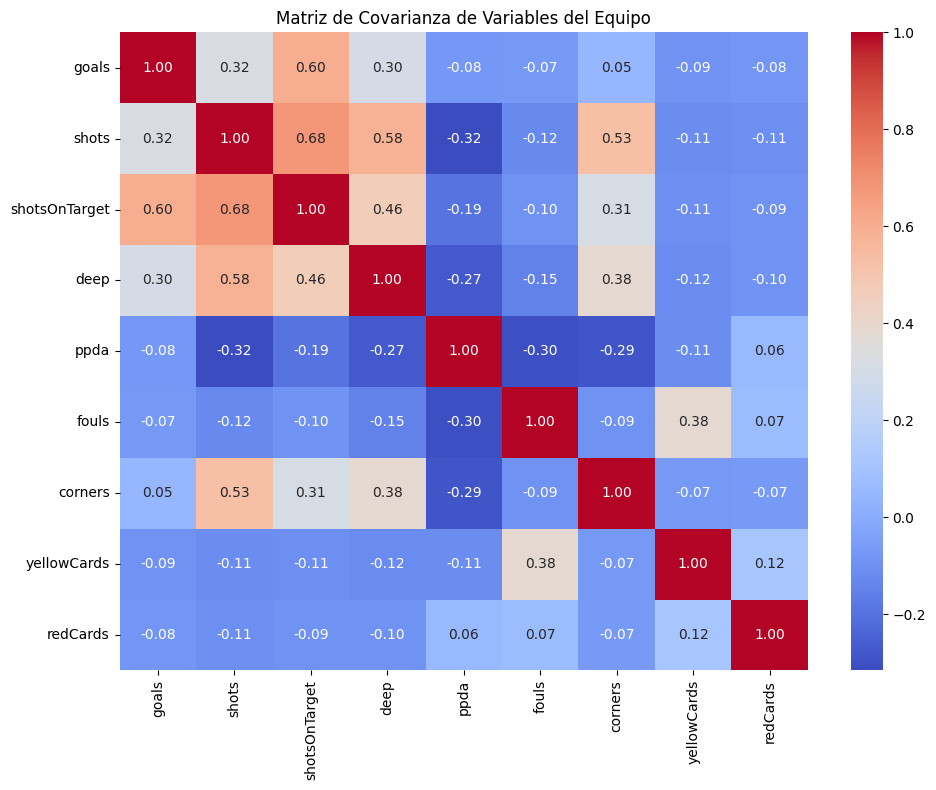

In [6]:
from scipy.linalg import convolution_matrix
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# =====================================================================
# 1. Importar los datos y separar la variable independiente
# =====================================================================
# Cargar el dataset
df = pd.read_csv('teamstats.csv')

# Lista de columnas solicitadas
features = ['goals', 'shots', 'shotsOnTarget', 'deep', 'ppda', 'fouls', 'corners', 'yellowCards', 'redCards']

# Separar las características (X) y la variable objetivo o independiente (y)
X = df[features]
# La variable independiente es el resultado final que tiene tres valores
# posibles: W, L, D
y = df['result']

# --- Manejo de valores NaN antes de la estandarización ---
# Se identificaron NaNs en 'yellowCards'. Se imputarán por la media.
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=features)

# Los datos se deben estandarizar antes de calcular la covarianza y el PCA
# para que todas las variables contribuyan equitativamente (media 0 y varianza 1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =====================================================================
# 2. Calcular la matriz de covarianza y graficar mapa de calor
# =====================================================================
# Calcular la matriz de covarianza sobre los datos estandarizados
cov_matrix = np.cov(X_scaled, rowvar=False)
# print("Matriz de correlación:",cov_matrix)

# Graficar la matriz de covarianza utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=features, yticklabels=features)
plt.title('Matriz de Covarianza de Variables del Equipo')
plt.tight_layout()
plt.show()

In [7]:
# =====================================================================
# 3. Realizar el análisis de componentes principales (PCA)
# =====================================================================
# Inicializamos y ajustamos el modelo PCA a toda la matriz estandarizada
pca = PCA()
pca.fit(X_scaled)


# =====================================================================
# 4. Obtener y mostrar los dos componentes principales (mayor varianza)
# =====================================================================
# Los componentes son los vectores propios (eigenvectors) ordenados
top_2_components = pca.components_[:2]
var_explicada = pca.explained_variance_ratio_ * 100
eigenvalues = pca.explained_variance_

#print("Componente 1: ",top_2_components[0,:])
#print("Componente 2: ",top_2_components[1,:])

print(f"Varianza explicada por el Componente 1: {var_explicada[0]:.2f}%")
print(f"Varianza explicada por el Componente 2: {var_explicada[1]:.2f}%")
print(f"Eigenvalues: {eigenvalues}")
#print("-" * 50)

print("Cargas (weights) del Componente Principal 1:")
for feature, weight in zip(features, top_2_components[0,:]):
    print(f" - {feature}: {weight:.4f}")

print("\nCargas (weights) del Componente Principal 2:")
for feature, weight in zip(features, top_2_components[1,:]):
    print(f" - {feature}: {weight:.4f}")

Varianza explicada por el Componente 1: 32.81%
Varianza explicada por el Componente 2: 17.45%
Eigenvalues: [2.95276528 1.57042535 1.10048038 0.97534838 0.71473105 0.56778511
 0.4810548  0.41895874 0.2188058 ]
Cargas (weights) del Componente Principal 1:
 - goals: 0.3280
 - shots: 0.5035
 - shotsOnTarget: 0.4759
 - deep: 0.4372
 - ppda: -0.2336
 - fouls: -0.1092
 - corners: 0.3540
 - yellowCards: -0.1260
 - redCards: -0.1166

Cargas (weights) del Componente Principal 2:
 - goals: -0.0940
 - shots: 0.0561
 - shotsOnTarget: -0.0182
 - deep: 0.0134
 - ppda: -0.5094
 - fouls: 0.6355
 - corners: 0.1099
 - yellowCards: 0.5447
 - redCards: 0.1239


In [8]:
# =====================================================================
# 5. Calcular las dos nuevas variables (Componentes) para cada fila
# =====================================================================
# Se aplica la transformación para proyectar los datos originales
# en el nuevo espacio bidimensional definido por los dos primeros componentes
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Se crea un nuevo DataFrame con estos resultados para facilitar la gráfica
df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])

# Se añade de vuelta la variable de etiqueta 'result' (ej. Win, Draw, Lose)
df_pca['result'] = y.values



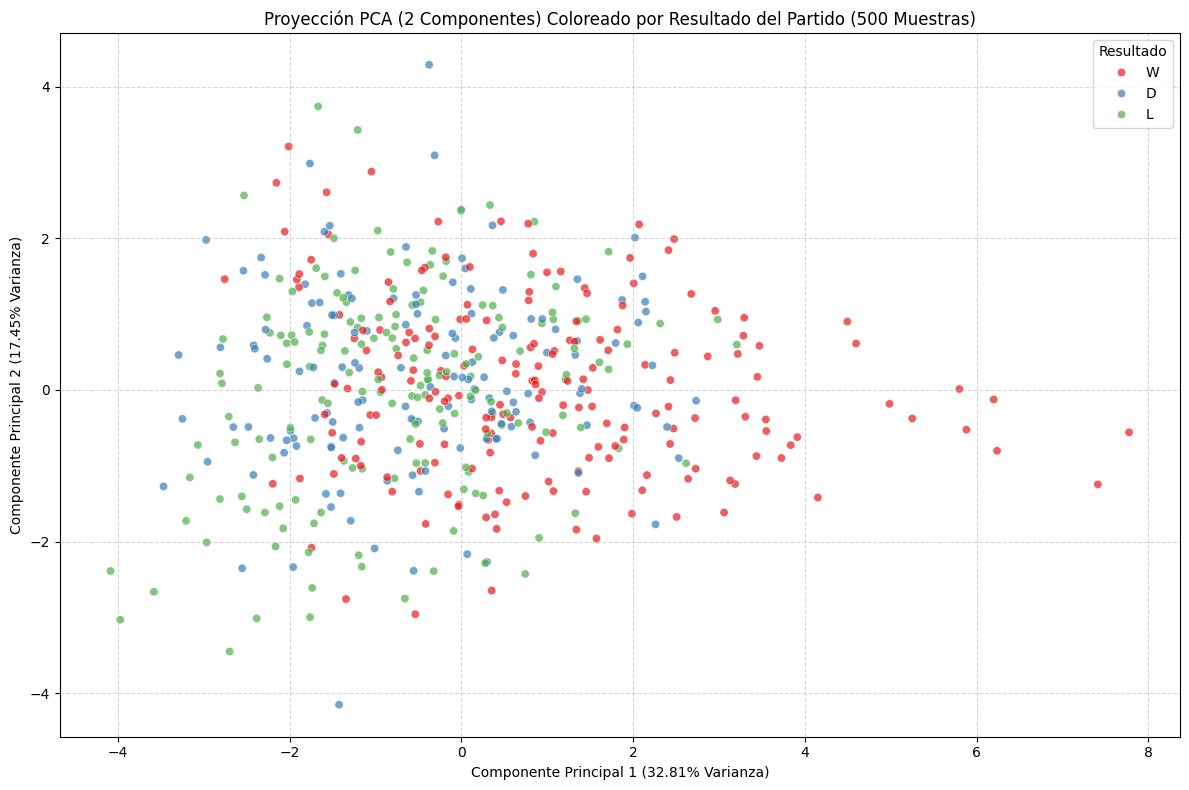

In [9]:
# =====================================================================
# 6. Realizar un gráfico tipo scatterplot coloreado por 'result'
# =====================================================================
# Seleccionamos 500 muestras aleatorias para graficar
df_pca_sampled = df_pca.sample(n=500, random_state=42)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='result',
    data=df_pca_sampled,
    palette='Set1',
    alpha=0.7
)

# Configuraciones del gráfico
plt.title('Proyección PCA (2 Componentes) Coloreado por Resultado del Partido (500 Muestras)')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]:.2f}% Varianza)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]:.2f}% Varianza)')
plt.legend(title='Resultado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# Realizar PCA con 3 componentes
pca_3 = PCA(n_components=3)
X_pca_3d = pca_3.fit_transform(X_scaled)

# Crear un DataFrame para el gráfico 3D
df_pca_3d = pd.DataFrame(data=X_pca_3d, columns=['Componente Principal 1', 'Componente Principal 2', 'Componente Principal 3'])
df_pca_3d['result'] = y.values

# Seleccionar 500 muestras aleatorias para graficar
df_pca_3d_sampled = df_pca_3d.sample(n=500, random_state=42)

# Filtrar para mostrar solo las categorías 'W' y 'L'
df_pca_3d_filtered = df_pca_3d_sampled[df_pca_3d_sampled['result'].isin(['W', 'L'])]

# Importar Plotly para gráficos interactivos
import plotly.express as px

# Crear el scatterplot 3D interactivo con Plotly
fig = px.scatter_3d(df_pca_3d_filtered,
                    x='Componente Principal 1',
                    y='Componente Principal 2',
                    z='Componente Principal 3',
                    color='result',
                    title='Proyección PCA (3 Componentes) Interactiva por Resultado del Partido (Categorías W y L)',
                    labels={
                        'Componente Principal 1': f'Componente Principal 1 ({var_explicada[0]:.2f}% Varianza)',
                        'Componente Principal 2': f'Componente Principal 2 ({var_explicada[1]:.2f}% Varianza)',
                        'Componente Principal 3': f'Componente Principal 3 ({var_explicada[2]:.2f}% Varianza)'
                    })

# Ajustar el tamaño y mostrar el gráfico interactivo
fig.update_layout(scene=dict(aspectmode='cube')) # Asegura una proporción de aspecto equitativa
fig.show()

## Reto
Utilice uno de los siguientes DataSets para reproducir la metodología de análsis de componentes principales. Analice sus resultados:

1. PMU Dataset for Power Line Fault Detection
2. Meteorological Data Set of the Canary Islands
3. Weather Forecast Dataset Dataset for Classification Problem - Machine Learning for Beginner
4. Un dataset de su preferencia.
